# Unit 4- ANOVAs
updated on 4/14/2026


In [2]:
pip install pingouin

Note: you may need to restart the kernel to use updated packages.


## Demo  1. One-way ANOVA 

One-way ANOVA (Independent samples)：抑郁干预三种方案（placebo, anxifree, joyzepam）， 情绪改善均值检验

1. 零假设
* H0: $\mu_{placebo}=\mu_{anxifree}=\mu_{joyzepam}$ is true
* H1: $\mu_{placebo},\mu_{anxifree},\mu_{joyzepam}$ 至少有两个不相等

2. Python 检验函数：
* pinguion.anova(), or DataFrame.anova(), 要求掌握）

3. posthoc 多重比较， 如果接受H1，希望进一步直到两些对的均值存在显著差异
*  pinguion.pairwise_tukey ( 要求了解）

In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

In [4]:
data=pd.read_csv("drugstudy.csv")
data

,ID,Group,MoodGain
0,1,placebo,0.5
1,2,placebo,0.3
2,3,placebo,0.1
3,4,anxifree,0.6
4,5,anxifree,0.4
5,6,anxifree,0.2
6,7,joyzepam,1.4
7,8,joyzepam,1.7
8,9,joyzepam,1.3
9,10,placebo,0.6


#### Visualizing the data with boxplot

<Axes: xlabel='Group', ylabel='MoodGain'>

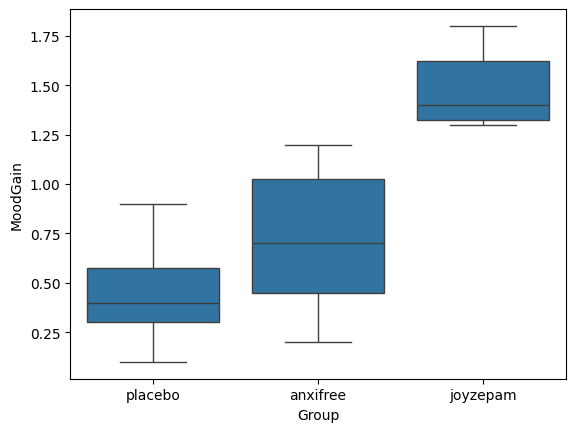

In [5]:
sns.boxplot(x="Group",y="MoodGain",data=data)

### ANOVA函数：pinguion包 

In [7]:
import pingouin as pg
aov=data.anova(dv='MoodGain', between="Group",detailed=True)
print(aov.round(6))

   Source        SS  DF        MS          F     p_unc       np2
0   Group  3.453333   2  1.726667  18.610778  0.000086  0.712762
1  Within  1.391667  15  0.092778        NaN       NaN       NaN


In [8]:
aov=pg.anova(dv="MoodGain",between="Group",data=data,detailed=True)
print(aov)

   Source        SS  DF        MS          F     p_unc       np2
0   Group  3.453333   2  1.726667  18.610778  0.000086  0.712762
1  Within  1.391667  15  0.092778        NaN       NaN       NaN


#### 1-Way ANOVA: Post Hoc 多重检验:
当one-way anova检验结果具有显著差异后，为了确定哪些对比具有差异，需要进行post hoc 比较：

In [9]:
## using pair-wise comparisons using pingouin.pairwise_tukey
pt=data.pairwise_tukey(dv='MoodGain', between='Group')

print(pt.round(4))

          A         B  mean_A  mean_B    diff      se       T  p_tukey  hedges
0  anxifree  joyzepam  0.7167  1.4833 -0.7667  0.1759 -4.3596   0.0015 -2.2417
1  anxifree   placebo  0.7167  0.4500  0.2667  0.1759  1.5164   0.3115  0.7217
2  joyzepam   placebo  1.4833  0.4500  1.0333  0.1759  5.8760   0.0001  3.8205


In [10]:
stats.ttest_ind(data[data.Group=="anxifree"].MoodGain,data[data.Group=="joyzepam"].MoodGain,equal_var=False)

TtestResult(statistic=np.float64(-4.206222496766865), pvalue=np.float64(0.00320741252343862), df=np.float64(7.73064118638938))

In [11]:
data[data.Group=="joyzepam"]

,ID,Group,MoodGain
6,7,joyzepam,1.4
7,8,joyzepam,1.7
8,9,joyzepam,1.3
15,16,joyzepam,1.8
16,17,joyzepam,1.3
17,18,joyzepam,1.4


In [12]:
?pg.pairwise_tukey

Signature: pg.pairwise_tukey(data=None, dv=None, between=None, effsize='hedges')
Docstring:
Pairwise Tukey-HSD post-hoc test.

Parameters
----------
data : :py:class:`pandas.DataFrame`
    DataFrame. Note that this function can also directly be used as a Pandas method, in which
    case this argument is no longer needed.
dv : string
    Name of column containing the dependent variable.
between: string
    Name of column containing the between factor.
effsize : string or None
    Effect size type. Available methods are:

    * ``'none'``: no effect size
    * ``'cohen'``: Unbiased Cohen d
    * ``'hedges'``: Hedges g
    * ``'r'``: Pearson correlation coefficient
    * ``'eta_square'``: Eta-square
    * ``'odds_ratio'``: Odds ratio
    * ``'AUC'``: Area Under the Curve
    * ``'CLES'``: Common Language Effect Size

Returns
-------
stats : :py:class:`pandas.DataFrame`

    * ``'A'``: Name of first measurement
    * ``'B'``: Name of second measurement
    * ``'mean_A'``: Mean of first mea

## Demo 2: One-way Repeated Measures ANOVA ： 
一个班的学生连续四次考试成绩的均值比较数据包括一个班的学生四次考试成绩，
* pinguion.rm_anova()--要求掌握


<Axes: xlabel='Test', ylabel='Scores'>

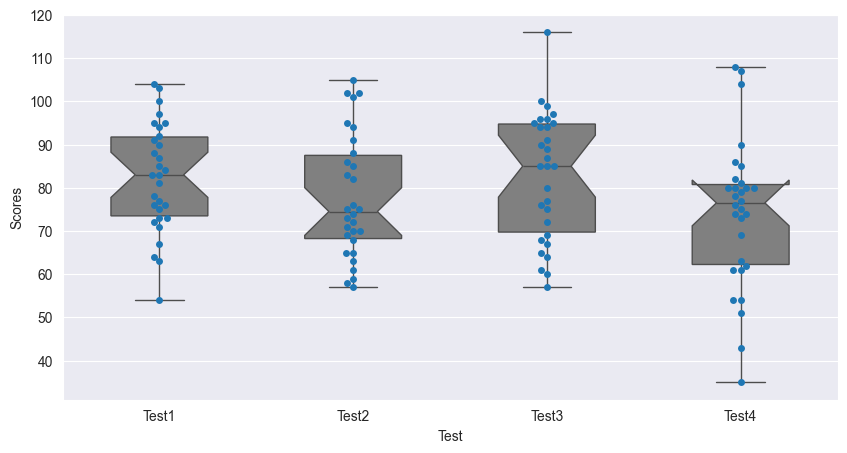

In [13]:
## Crreating the simulated data 
mu=[80,83 ,85,80]
sigma=[15,15,15,15]
n=30
score=[]
test=[]
np.random.seed(100)
for i in np.arange(len(mu)):
    data=np.round(stats.norm.rvs(mu[i],sigma[i],size=n),0)
    score=np.append(score,data)
    test+=["Test"+str(i+1)]*n
data=pd.DataFrame({"Scores":score,"Test":test,"Sub_id":list(np.arange(n)+1)*4})    
##let's visulize the data
sns.set_style("darkgrid")
plt.figure(figsize=(10,5))

sns.swarmplot(x="Test",y="Scores",data=data)
#sns.violinplot(x="Test",y="Scores",data=data,linewidth=1,color="grey",alpha=0.2,inner="quartile",bw=0.2)
sns.boxplot(x="Test",y="Scores",data=data,linewidth=1,color="grey",width=0.5,notch=True)

In [14]:
data.head(31)

,Scores,Test,Sub_id
0,54.0,Test1,1
1,85.0,Test1,2
2,97.0,Test1,3
3,76.0,Test1,4
4,95.0,Test1,5
5,88.0,Test1,6
6,83.0,Test1,7
7,64.0,Test1,8
8,77.0,Test1,9
9,84.0,Test1,10


#### One-way Repeated measures ANOVA: pingouin.rm_anova

In [15]:
import pingouin as pg
aov = pg.rm_anova(data=data, dv='Scores', subject="Sub_id",within='Test', detailed=True)
print(aov)


  Source            SS  DF          MS         F     p_unc       ng2       eps
0   Test   1542.758333   3  514.252778  2.720667  0.049308  0.058073  0.911321
1  Error  16444.491667  87  189.017146       NaN       NaN       NaN       NaN


#### Posthoc 多重比较 for 1-Way repeated measure ANOVA

In [16]:
mc=data.pairwise_ttests(dv="Scores",within="Test",subject="Sub_id",padjust="bonf")
print(mc.round(4))

  Contrast      A      B  Paired  Parametric       T   dof alternative  \
0     Test  Test1  Test2    True        True  1.3860  29.0   two-sided   
1     Test  Test1  Test3    True        True -0.1419  29.0   two-sided   
2     Test  Test1  Test4    True        True  2.7913  29.0   two-sided   
3     Test  Test2  Test3    True        True -1.3180  29.0   two-sided   
4     Test  Test2  Test4    True        True  0.9284  29.0   two-sided   
5     Test  Test3  Test4    True        True  2.3106  29.0   two-sided   

    p_unc  p_corr p_adjust   BF10  hedges  
0  0.1763  1.0000     bonf  0.461  0.3341  
1  0.8882  1.0000     bonf  0.196 -0.0339  
2  0.0092  0.0551     bonf  4.838  0.5487  
3  0.1978  1.0000     bonf  0.426 -0.3418  
4  0.3609  1.0000     bonf  0.288  0.2367  
5  0.0282  0.1690     bonf  1.901  0.5450  


e:\anaconda3\envs\med_env\lib\site-packages\pingouin\pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


In [17]:
aov=data.anova(dv='Scores', between="Test",detailed=True)
print(aov)

   Source            SS   DF          MS         F     p_unc       np2
0    Test   1542.758333    3  514.252778  2.383924  0.072872  0.058073
1  Within  25023.166667  116  215.716954       NaN       NaN       NaN


## Demo 3: Two-way ANOVA

In [18]:
data=pd.read_csv("drugstudy2.csv")
data.head()

,Subject,Drug,Therapy,MoodGain
0,1,placebo,no.therapy,0.5
1,2,placebo,no.therapy,0.3
2,3,placebo,no.therapy,0.1
3,4,anxifree,no.therapy,0.6
4,5,anxifree,no.therapy,0.4


In [19]:
import pingouin as pg
aov=data.anova(dv='MoodGain', between=["Drug","Therapy"],detailed=True)
print(aov.round(6))

           Source        SS  DF        MS          F     p_unc       np2
0            Drug  3.453333   2  1.726667  31.714286  0.000016  0.840909
1         Therapy  0.467222   1  0.467222   8.581633  0.012617  0.416956
2  Drug * Therapy  0.271111   2  0.135556   2.489796  0.124602  0.293269
3        Residual  0.653333  12  0.054444        NaN       NaN       NaN


## Demo 4: Two way repeated measure ANOVA (两因素重复测量方差分析）
招募了8名被试（4名青年，4名老年人），进行了一项心理学测试，在三种干扰因素下（如干扰（闭眼），简单干扰，复杂干扰刺激），分别检测被试的心理测试成绩（Scores), 整个过程重复两次（Day1, Day2)。利用重复测量方差分析，研究：


（1）三个不同干扰因素下是否有不同作用？
（2）两天的测试有无差异？
（3）干扰因素的影响在两次重复测量中是否相同？

In [20]:
data=pd.read_csv("anovademo_new.csv")

In [21]:
data.head(10)

,Test_Order,Distractions,Scores,Subjects,Age
0,Day1,Closed Eyes,8,1,Yong
1,Day1,Closed Eyes,7,2,Yong
2,Day1,Closed Eyes,8,3,Yong
3,Day1,Closed Eyes,7,4,Yong
4,Day1,Closed Eyes,6,5,Old
5,Day1,Closed Eyes,5,6,Old
6,Day1,Closed Eyes,5,7,Old
7,Day1,Closed Eyes,6,8,Old
8,Day1,Simple Distraction,5,1,Yong
9,Day1,Simple Distraction,6,2,Yong


In [22]:
aov=pg.rm_anova(dv="Scores",within=["Test_Order","Distractions"],subject="Subjects",data=data,correction=True,detailed=True)
print(aov)

                      Source         SS  ddof1  ddof2         MS          F  \
0                 Test_Order  21.333333      1      7  21.333333  17.230769   
1               Distractions  75.875000      2     14  37.937500  22.015544   
2  Test_Order * Distractions   2.541667      2     14   1.270833   1.552727   

      p_unc  p_GG_corr       ng2       eps  
0  0.004290   0.004290  0.171237  1.000000  
1  0.000048   0.000402  0.423587  0.720883  
2  0.246011   0.249743  0.024025  0.852997  


<Axes: xlabel='Distractions', ylabel='Scores'>

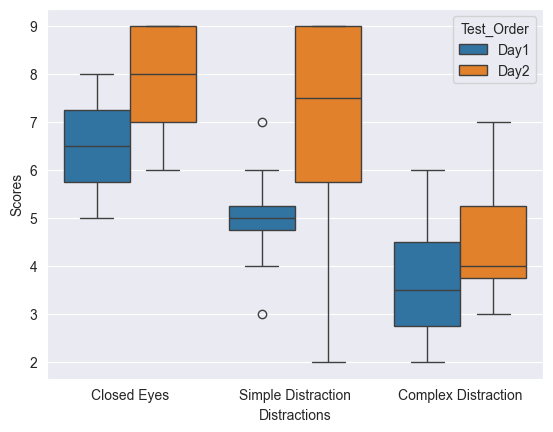

In [23]:
sns.boxplot(hue="Test_Order",y="Scores",x="Distractions",data=data)


## Demo 5: Two-way Mixed ANOVA(本课程不做要求）

#### Mixed ANOVA（本课程不做要求）: 当既有between 因素，又有winthin因素。 比如招募男性和女性志愿者，分别在三种状态(state)，这时候如果要研究性别, 状态及其交互作用，那么性别是组间因素， 状态是组内因素。可以利用pg.mixed_anova来分析

In [24]:
aov=pg.mixed_anova(dv="Scores",within="Distractions",between="Age",subject="Subjects",data=data,correction=True)
print(aov)

         Source         SS  DF1  DF2         MS          F     p_unc  \
0           Age  15.041667    1    6  15.041667   6.242075  0.046628   
1  Distractions  37.937500    2   12  18.968750  19.303887  0.000178   
2   Interaction   0.270833    2   12   0.135417   0.137809  0.872624   

   p_GG_corr       np2       eps sphericity   W_spher   p_spher  
0        NaN  0.509887       NaN        NaN       NaN       NaN  
1   0.000402  0.762882  0.720883       True  0.612813  0.230136  
2        NaN  0.022453       NaN        NaN       NaN       NaN  


## 课堂，课后复习题：
One-way repeated measure ANOVA
6个中风后语言障碍的病人，分别进行了三种语言测试任务： Speak(说), Conceptual（概念）, Syntax（句法规则），
每个人测试十次，下面的表格是每个病人，每种测试任务下成功的次数，请检验三种任务完成是否具有显著差异？



In [25]:
aphasia=pd.read_csv("aphasia.csv")

In [26]:
aphasia.head()

,Subject,Test,Score,Unnamed: 3
0,1,Speech,8,NaN
1,2,Speech,7,NaN
2,3,Speech,9,NaN
3,4,Speech,5,NaN
4,5,Speech,6,NaN


1. 正态性检验 using stats.shapiro, when p>0.05, we can't reject the hypothesis that the data is normally distributed

In [27]:
speech=aphasia[aphasia.Test=="Speech"].Score
conceptual=aphasia[aphasia.Test=="Conceptual"].Score
syntax=aphasia[aphasia.Test=="Syntax"].Score

In [28]:
## test with stats.shapiro



2. One-way repeated measures ANOVA with pengouin.rm_anova, including sphericity test 

In [29]:
# using aov=pg.rm_anova( )
# print(aov)

3. 如果1-way repeated measure ANOVA 显示了显著的主效应，再用posthoc多重比较,看看具体哪些组间有差异，采用Bonferroni 进行p值校正


函数：pengouin.pairwise_ttests

In [30]:
# using: mc=pg.pairwise_ttests( )
# print(mc.round(4))